# Shuffled-Label UdonPred Null Workflow

Retrain UdonPred on each of the seven datasets after residue-level label shuffling, then evaluate the full 7x7 matrix to estimate empirical null performance. Use the `Protein Prediction (UdonPred uv)` kernel.

## 1. Setup

In [19]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "UdonPred").exists():
    ROOT = ROOT.parent

DATASETS = ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt", "disprot"]
METRIC_COLUMNS = ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt", "disprot\n(AP)", "disprot\n(AUROC)"]
RESULT_DIR = ROOT / "results" / "udonpred_shuffled_labels"

print("Python:", sys.version)
print("Project root:", ROOT)
print("Result dir:", RESULT_DIR)

Python: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
Project root: c:\Users\Apple\Desktop\Protein_Prediction
Result dir: c:\Users\Apple\Desktop\Protein_Prediction\results\udonpred_shuffled_labels


## 2. CUDA Check

In [20]:
cuda_cmd = ["uv", "run", "python", str(ROOT / "scripts" / "check_gpu.py")]
print(" ".join(cuda_cmd))
subprocess.run(cuda_cmd, cwd=ROOT / "UdonPred", check=True)

uv run python c:\Users\Apple\Desktop\Protein_Prediction\scripts\check_gpu.py


CompletedProcess(args=['uv', 'run', 'python', 'c:\\Users\\Apple\\Desktop\\Protein_Prediction\\scripts\\check_gpu.py'], returncode=0)

## 3. Dataset And Label Sanity Checks

In [21]:
def read_jsonl(path):
    with path.open() as handle:
        return [json.loads(line) for line in handle if line.strip()]

rows = []
for dataset in DATASETS:
    dataset_dir = ROOT / "UdonPred" / "data" / dataset
    for split in ["train", "valid", "test"]:
        records = read_jsonl(dataset_dir / f"{split}.jsonl")
        residues = 0
        valid_labels = 0
        masked_labels = 0
        bad_lengths = []
        for record in records:
            sequence = str(record["x_0"])
            labels = record["y"]
            residues += len(sequence)
            valid_labels += sum(1 for value in labels if value != 999)
            masked_labels += sum(1 for value in labels if value == 999)
            if len(sequence) != len(labels):
                bad_lengths.append(record["id"])
        rows.append({
            "dataset": dataset,
            "split": split,
            "records": len(records),
            "residues": residues,
            "valid_labels": valid_labels,
            "masked_labels": masked_labels,
            "bad_lengths": len(bad_lengths),
        })

sanity = pd.DataFrame(rows)
display(sanity)
assert sanity["bad_lengths"].sum() == 0, "Found sequence/label length mismatches"

,dataset,split,records,residues,valid_labels,masked_labels,bad_lengths
0,trizod,train,3867,443939,407194,36745,0
1,trizod,valid,685,82523,77160,5363,0
2,trizod,test,348,38526,37133,1393,0
3,chezod,train,697,88361,84653,3708,0
4,chezod,valid,117,14112,13334,778,0
5,chezod,test,117,13952,13068,884,0
6,softdis,train,11486,3470959,3470959,0,0
7,softdis,valid,1484,424887,424887,0,0
8,softdis,test,1869,271668,271668,0,0
9,pdbflex,train,9233,2880938,2880938,0,0


## 4. Launch Shuffled Null Runs

This is expensive: the default runs 3 seeds x 7 training datasets, exports 21 heads, and evaluates 147 prediction jobs.

In [22]:
RUN_NULL_WORKFLOW = True

SEEDS = [13]
DEVICE = "cuda"
BATCH_SIZE = 100
SMOOTH = 1.5

# Optional smoke-run controls. Leave DATASETS as-is for the full workflow.
RUN_DATASETS = DATASETS
NUM_TRAIN_EPOCHS = 5

cmd = [
    "uv", "run", "python",
    str(ROOT / "scripts" / "run_udonpred_shuffled_null.py"),
    "--udonpred-dir", str(ROOT / "UdonPred"),
    "--output-dir", str(RESULT_DIR),
    "--device", DEVICE,
    "--batch-size", str(BATCH_SIZE),
    "--smooth", str(SMOOTH),
    "--seeds", *map(str, SEEDS),
    "--datasets", *RUN_DATASETS,
]
if NUM_TRAIN_EPOCHS is not None:
    cmd += ["--num-train-epochs", str(NUM_TRAIN_EPOCHS)]

print(" ".join(cmd))
if RUN_NULL_WORKFLOW:
    subprocess.run(cmd, cwd=ROOT / "UdonPred", check=True)
else:
    print("Set RUN_NULL_WORKFLOW = True to launch the shuffled-label null workflow.")

uv run python c:\Users\Apple\Desktop\Protein_Prediction\scripts\run_udonpred_shuffled_null.py --udonpred-dir c:\Users\Apple\Desktop\Protein_Prediction\UdonPred --output-dir c:\Users\Apple\Desktop\Protein_Prediction\results\udonpred_shuffled_labels --device cuda --batch-size 100 --smooth 1.5 --seeds 13 --datasets trizod chezod softdis pdbflex atlas plddt disprot --num-train-epochs 5


## 5. Load Null Matrices

In [23]:
matrix_rows = []
for path in sorted(RESULT_DIR.glob("seed_*/matrix.csv")):
    seed = int(path.parent.name.split("_", 1)[1])
    matrix = pd.read_csv(path)
    matrix["seed"] = seed
    matrix_rows.append(matrix)

if matrix_rows:
    null_matrices = pd.concat(matrix_rows, ignore_index=True)
    display(null_matrices)
else:
    null_matrices = pd.DataFrame(columns=["seed", "train_dataset", *METRIC_COLUMNS])
    print(f"No shuffled null matrices found under {RESULT_DIR}")
    print("Run section 4 with RUN_NULL_WORKFLOW = True, or point RESULT_DIR at an existing shuffled-label output directory.")

,train_dataset,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot\n(AP),disprot\n(AUROC),seed
0,trizod,-0.115592,0.096605,-0.253083,-0.131159,-0.358341,0.050424,0.382120,0.581186,13
1,chezod,-0.296455,-0.207731,-0.333484,-0.091588,-0.410959,-0.361702,0.227606,0.308080,13
2,softdis,0.137679,0.524019,-0.083614,0.003843,0.210170,0.521781,0.628979,0.821124,13
3,pdbflex,0.159663,0.493628,-0.068753,-0.029903,0.234651,0.532814,0.587177,0.805662,13
4,atlas,-0.126227,-0.445006,0.074813,0.114774,-0.204216,-0.456655,0.197480,0.169990,13
5,plddt,-0.217218,-0.268360,-0.239072,0.051297,-0.153042,-0.499035,0.201240,0.181045,13
6,disprot,-0.041595,-0.100609,0.009983,0.067916,-0.008855,-0.074386,0.298972,0.486466,13


## 6. Null Summary

In [24]:
if null_matrices.empty:
    long_null = pd.DataFrame(columns=["seed", "train_dataset", "test_metric", "score"])
    summary = pd.DataFrame(columns=["train_dataset", "test_metric", "n", "mean", "std", "q025", "q500", "q975"])
    print("No null matrices loaded; skipping summary until matrix.csv files exist.")
else:
    long_null = null_matrices.melt(
        id_vars=["seed", "train_dataset"],
        value_vars=METRIC_COLUMNS,
        var_name="test_metric",
        value_name="score",
    ).dropna()

    summary = (
        long_null.groupby(["train_dataset", "test_metric"])["score"]
        .agg(
            n="count",
            mean="mean",
            std="std",
            q025=lambda s: s.quantile(0.025),
            q500="median",
            q975=lambda s: s.quantile(0.975),
        )
        .reset_index()
    )
    display(summary)

,train_dataset,test_metric,n,mean,std,q025,q500,q975
0,atlas,atlas,1,-0.204216,NaN,-0.204216,-0.204216,-0.204216
1,atlas,chezod,1,-0.445006,NaN,-0.445006,-0.445006,-0.445006
2,atlas,disprot\n(AP),1,0.197480,NaN,0.197480,0.197480,0.197480
3,atlas,disprot\n(AUROC),1,0.169990,NaN,0.169990,0.169990,0.169990
4,atlas,pdbflex,1,0.114774,NaN,0.114774,0.114774,0.114774
5,atlas,plddt,1,-0.456655,NaN,-0.456655,-0.456655,-0.456655
6,atlas,softdis,1,0.074813,NaN,0.074813,0.074813,0.074813
7,atlas,trizod,1,-0.126227,NaN,-0.126227,-0.126227,-0.126227
8,chezod,atlas,1,-0.410959,NaN,-0.410959,-0.410959,-0.410959
9,chezod,chezod,1,-0.207731,NaN,-0.207731,-0.207731,-0.207731


## 7. Heatmaps

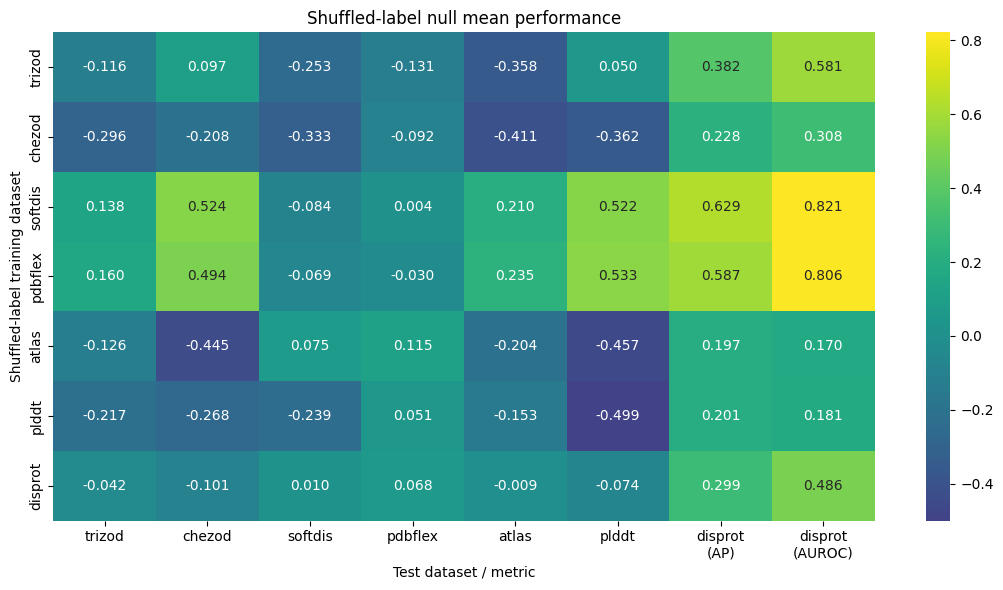

In [25]:
if summary.empty:
    mean_matrix = pd.DataFrame(index=DATASETS, columns=METRIC_COLUMNS, dtype=float)
    print("No null summary available; skipping null heatmap.")
else:
    mean_matrix = summary.pivot(index="train_dataset", columns="test_metric", values="mean").reindex(index=DATASETS, columns=METRIC_COLUMNS)

    plt.figure(figsize=(11, 6))
    sns.heatmap(mean_matrix, annot=True, fmt=".3f", cmap="viridis", center=0)
    plt.xlabel("Test dataset / metric")
    plt.ylabel("Shuffled-label training dataset")
    plt.title("Shuffled-label null mean performance")
    plt.tight_layout()
    plt.show()

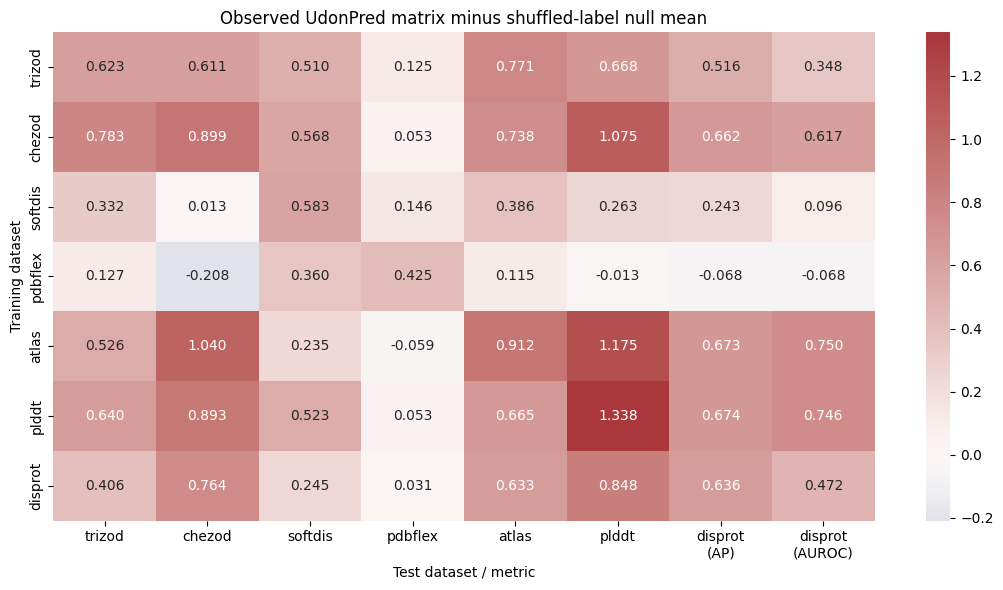

In [26]:
observed_path = ROOT / "results" / "udonpred_matrix" / "matrix.csv"
if summary.empty:
    print("No null summary available; skipping observed-minus-null heatmap.")
elif observed_path.exists():
    observed = pd.read_csv(observed_path).set_index("train_dataset").reindex(index=DATASETS, columns=METRIC_COLUMNS)
    delta = observed - mean_matrix
    plt.figure(figsize=(11, 6))
    sns.heatmap(delta, annot=True, fmt=".3f", cmap="vlag", center=0)
    plt.xlabel("Test dataset / metric")
    plt.ylabel("Training dataset")
    plt.title("Observed UdonPred matrix minus shuffled-label null mean")
    plt.tight_layout()
    plt.show()
else:
    print(f"Observed matrix not found: {observed_path}")

## 8. Distribution View

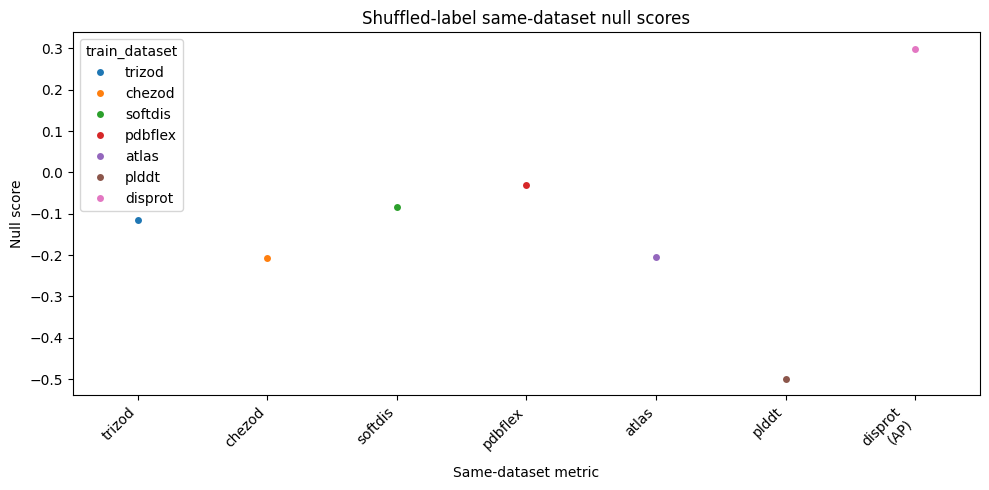

In [27]:
if long_null.empty:
    print("No null scores available; skipping distribution plot.")
else:
    diagonal_metrics = [dataset for dataset in DATASETS if dataset != "disprot"] + ["disprot\n(AP)", "disprot\n(AUROC)"]
    plot_rows = []
    for dataset in DATASETS:
        metric = dataset if dataset != "disprot" else "disprot\n(AP)"
        plot_rows.append(long_null[(long_null["train_dataset"] == dataset) & (long_null["test_metric"] == metric)])
    diagonal_null = pd.concat(plot_rows, ignore_index=True)

    plt.figure(figsize=(10, 5))
    sns.stripplot(data=diagonal_null, x="test_metric", y="score", hue="train_dataset", dodge=False)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Same-dataset metric")
    plt.ylabel("Null score")
    plt.title("Shuffled-label same-dataset null scores")
    plt.tight_layout()
    plt.show()